### Load example data (from CSL-SHARE database)

In [20]:
import numpy as np
import utils

train_data, y_train, test_data, y_test = utils.get_train_test_data()

print("# Train : ", len(train_data))
print("# Test  : ", len(test_data))
print("Class Labels : ", set(y_train))

# Train :  2095
# Test  :  655
Class Labels :  {'stand', 'walk', 'sit', 'sit-to-stand', 'walk-curve-right', 'stand-to-sit', 'walk-curve-left'}


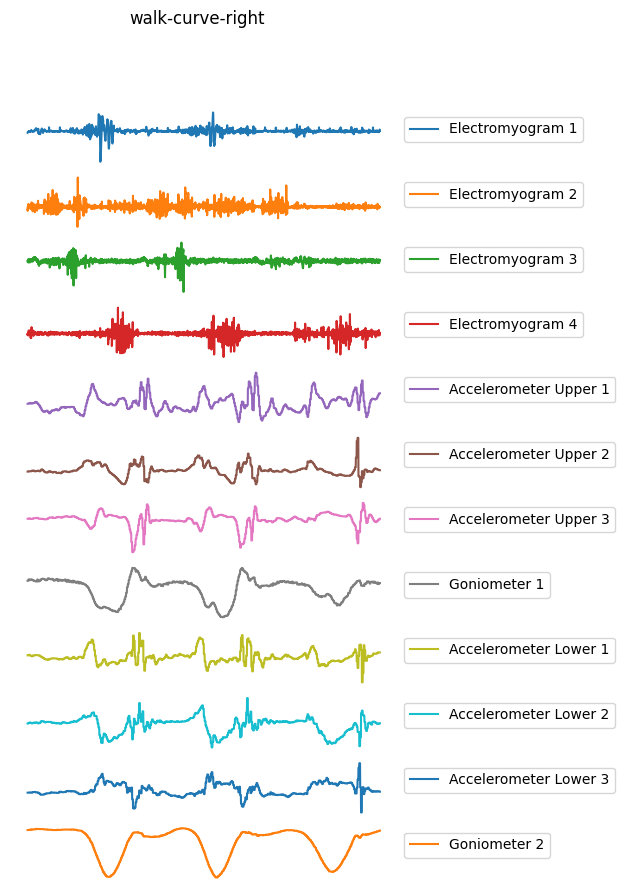

In [21]:
sample, label = utils.plot_random_sample_by_class(train_data, y_train, "walk-curve-right", ylim=False)


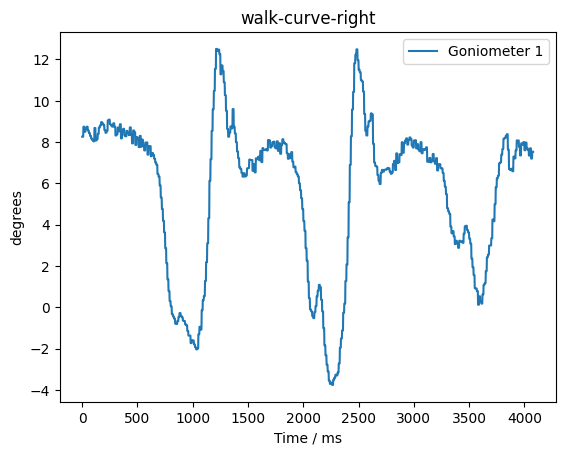

In [22]:
utils.plot_sensor_data(sample, label, "Goniometer 1")

In [23]:
train_data[0]

,Electromyogram 1,Electromyogram 2,Electromyogram 3,Electromyogram 4,Accelerometer Upper 1,Accelerometer Upper 2,Accelerometer Upper 3,Goniometer 1,Accelerometer Lower 1,Accelerometer Lower 2,Accelerometer Lower 3,Goniometer 2
0,-0.002930,-0.086105,0.001785,0.027878,0.0556,0.2498,-0.9136,-5.506845,0.2236,0.7376,0.4456,-81.842242
1,-0.001419,-0.055939,-0.004440,0.021469,0.0556,0.2498,-0.9136,-5.506845,0.2236,0.7376,0.4456,-81.842242
2,0.002289,-0.018906,0.003021,0.018631,0.0556,0.2498,-0.9136,-5.506845,0.2236,0.7376,0.4456,-81.842242
3,0.000916,0.058182,0.004761,0.024216,0.0556,0.2498,-0.9136,-5.506845,0.2236,0.7376,0.4456,-81.842242
4,0.001373,0.095581,-0.000641,0.016983,0.0556,0.2498,-0.9136,-5.506845,0.2236,0.7376,0.4456,-81.842242
...,...,...,...,...,...,...,...,...,...,...,...,...
2595,-0.001694,0.003159,0.004303,0.019867,0.1264,0.8160,0.3254,5.320514,0.2344,0.7200,0.4856,-20.503996
2596,-0.001282,0.002884,0.000641,0.024399,0.1264,0.8160,0.3254,5.320514,0.2344,0.7200,0.4856,-20.503996
2597,0.000000,0.001328,0.004532,0.016983,0.1264,0.8160,0.3254,5.320514,0.2344,0.7200,0.4856,-20.503996
2598,0.001373,-0.000046,-0.000961,0.030533,0.1264,0.8160,0.3254,5.320514,0.2344,0.7200,0.4856,-20.503996


### Feature Extraction with TSFEL

In [24]:
import tsfel

cfg = tsfel.get_features_by_domain("statistical") 

X_train = tsfel.time_series_features_extractor(cfg, train_data, fs=1000)
X_test = tsfel.time_series_features_extractor(cfg, test_data, fs=1000)


In [25]:
X_train

,Accelerometer Lower 1_Absolute energy,Accelerometer Lower 1_Average power,Accelerometer Lower 1_ECDF Percentile Count_0,Accelerometer Lower 1_ECDF Percentile Count_1,Accelerometer Lower 1_ECDF Percentile_0,Accelerometer Lower 1_ECDF Percentile_1,Accelerometer Lower 1_ECDF_0,Accelerometer Lower 1_ECDF_1,Accelerometer Lower 1_ECDF_2,Accelerometer Lower 1_ECDF_3,...,Goniometer 2_Mean,Goniometer 2_Mean absolute deviation,Goniometer 2_Median,Goniometer 2_Median absolute deviation,Goniometer 2_Min,Goniometer 2_Peak to peak distance,Goniometer 2_Root mean square,Goniometer 2_Skewness,Goniometer 2_Standard deviation,Goniometer 2_Variance
0,136.442876,52.498221,520.0,2080.0,0.1834,0.2488,0.000385,0.000769,0.001154,0.001538,...,-56.351328,24.761148,-71.186107,10.827359,-82.270301,61.947600,62.138305,0.352932,26.185814,685.696829
1,97.101582,59.244406,328.0,1312.0,0.1268,0.2808,0.000610,0.001220,0.001829,0.002439,...,-57.712279,19.783371,-67.517395,11.791749,-80.321376,59.021695,61.744324,0.558851,21.946626,481.654378
2,76.309068,51.248535,298.0,1192.0,0.1504,0.2704,0.000671,0.001342,0.002013,0.002685,...,-60.021304,18.383195,-69.267398,10.197861,-80.391880,58.341838,63.458759,0.642129,20.602358,424.457159
3,97.965594,50.785689,386.0,1544.0,0.1592,0.2608,0.000518,0.001036,0.001554,0.002073,...,-58.831072,19.563307,-69.146535,10.479876,-80.366700,60.265583,62.700943,0.589386,21.686708,470.313313
4,91.957968,47.919733,384.0,1536.0,0.1692,0.2480,0.000521,0.001042,0.001563,0.002083,...,-61.443032,19.847380,-74.960575,6.529149,-81.963106,61.146879,65.308691,0.698500,22.135468,489.978945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,104.669074,26.505210,790.0,3160.0,-0.1030,0.1332,0.000253,0.000506,0.000759,0.001013,...,-16.420096,12.700647,-7.611885,2.941013,-51.263767,47.841818,22.313245,-1.161822,15.108321,228.261360
2091,141.215270,37.074106,762.0,3048.0,-0.1232,0.1184,0.000262,0.000525,0.000787,0.001050,...,-16.382039,12.676176,-8.206131,3.575546,-51.485350,47.861962,22.231002,-1.126556,15.028182,225.846243
2092,119.648296,29.477284,812.0,3248.0,-0.1136,0.1360,0.000246,0.000493,0.000739,0.000985,...,-15.211850,12.273394,-6.496415,2.364393,-49.591821,46.814478,21.132732,-1.168767,14.669424,215.191989
2093,119.255566,29.380529,812.0,3248.0,-0.0928,0.1368,0.000246,0.000493,0.000739,0.000985,...,-15.791261,12.139524,-7.390302,3.044250,-48.524193,45.625986,21.386875,-1.124074,14.423401,208.034499


### Classification with TSFEL

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# Remove correlated features
corr_feat = tsfel.correlated_features(X_train)
X_train.drop(corr_feat, axis=1, inplace=True)
X_test.drop(corr_feat, axis=1, inplace=True)

# Classification
clf = RandomForestClassifier(max_depth=5, random_state=1)
clf.fit(X_train, y_train)
y_pred_train = clf.predict(X_train)
y_pred = clf.predict(X_test)

print(f"Accuracy - TRAIN: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy - TEST : {accuracy_score(y_test, y_pred):.3f}")


Accuracy - TRAIN: 0.922
Accuracy - TEST : 0.763


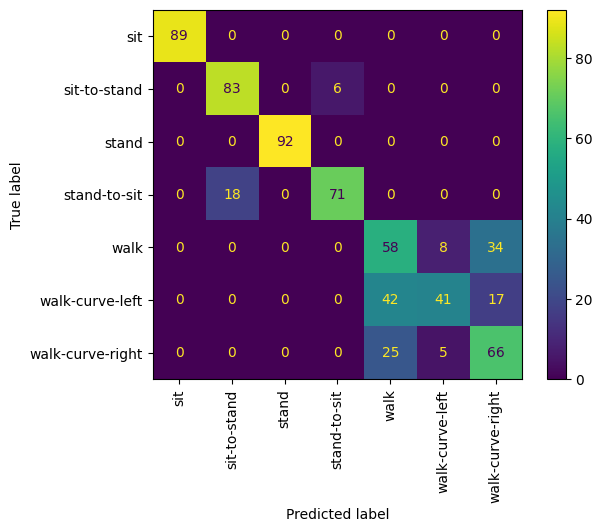

In [27]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation="vertical") #, cmap="Greens")

### Adding temporal features

In [8]:
cfg = tsfel.get_features_by_domain(["statistical","temporal"])

X_train = tsfel.time_series_features_extractor(cfg, train_data, fs=1000)
X_test = tsfel.time_series_features_extractor(cfg, test_data, fs=1000)

# Remove correlated features
corr_feat, X_train = tsfel.correlated_features(X_train, drop_correlated=True)
X_test.drop(corr_feat, axis=1, inplace=True)

# Classification
clf = RandomForestClassifier(max_depth=5, random_state=1)
clf.fit(X_train, y_train)
y_pred_train = clf.predict(X_train)
y_pred = clf.predict(X_test)

print(f"Accuracy - TRAIN: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy - TEST : {accuracy_score(y_test, y_pred):.3f}")

Accuracy - TRAIN: 0.971
Accuracy - TEST : 0.809


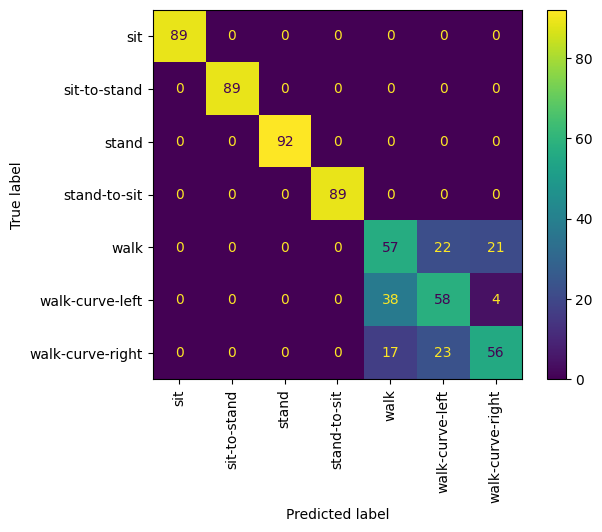

In [9]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation="vertical") #, cmap="Greens")